<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/C%C3%B3pia_de_RL_Aula2_Sincrona_DQN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gymnasium as gym
from gymnasium import spaces

import numpy as np
from scipy.integrate import solve_ivp
from itertools import product



In [2]:
class CSTRControlEnv(gym.Env):
    def __init__(self):
        super().__init__()

        # Espaços de ação: Controle discreto para agente de resfriamento e válvula de alívio
        self.action_space = spaces.Discrete(9)
        self.action_mapping = list(product(range(3), range(3)))

        # Espaços de observação: Erros normalizados de temperatura e pressão
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)

        # Parâmetros do reator
        self.params = {
            "V": 1.0,  # Volume do reator (m³)
            "Cp": 4.18e3,  # Capacidade térmica do líquido (J/kg·K)
            "rho": 1000,  # Densidade do líquido (kg/m³)
            "k_reaction": 5e-1,  # Constante de reação exotérmica
            "delta_Hr": -5e5,  # Calor liberado pela reação (J/mol)
            "P_inert": 1e5,  # Pressão inicial do gás inerte (Pa)
            "T_cool": 298.0,  # Temperatura do agente de resfriamento (K)
            "T_ambient": 298.0,  # Temperatura ambiente (K)
            "tau": 100.0,  # Constante de troca térmica (s)
            "T_setpoint": 350.0,  # Setpoint de temperatura (K)
            "P_setpoint": 2e5,  # Setpoint de pressão (Pa)
            "R": 8.314,  # Constante universal dos gases (J/mol·K)
        }

        # Vazões manipuladas
        self.coolant_flow = 0.0  # Vazão inicial do agente de resfriamento (kg/s)
        self.vent_flow = 0.0  # Vazão inicial do gás liberado (kg/s)

        self.reset()

    def reset(self, seed=None):
        # Condições iniciais do reator
        self.state = {
            "T": 298.0,  # Temperatura inicial (K)
            "P": 101325,  # Pressão inicial (Pa)
        }
        self.iteration = 0
        return self._get_normalized_state()

    def step(self, action):
        # Ajustar as vazões com base na ação
        coolant_action, vent_action = self.action_mapping[action]
        self.coolant_flow += (coolant_action - 1) * 0.001  # Incremento de -0.005, 0, +0.005
        self.vent_flow += (vent_action - 1) * 0.001  # Incremento de -0.001, 0, +0.001
        self.coolant_flow = max(0, self.coolant_flow)  # Garantir que a vazão não seja negativa
        self.vent_flow = max(0, self.vent_flow)

        # Resolver as EDOs do reator
        t_span = [0, 10]  # Passo de tempo de 1 segundo
        y0 = [self.state["T"], self.state["P"]]  # Condições iniciais
        sol = solve_ivp(self._reactor_model, t_span, y0, args=(self.coolant_flow, self.vent_flow))

        # Atualizar o estado do reator
        self.state["T"], self.state["P"] = sol.y[:, -1]

        # Calcular erros e recompensa
        error_T = (self.state["T"] - self.params["T_setpoint"]) /(350 - 300)
        error_P = (self.state["P"] - self.params["P_setpoint"]) / (4e5 - 0.5e5)
        reward = 2- (abs(error_T) + abs(error_P))  # Recompensa baseada nos erros absolutos

        # Incrementar o contador de iterações
        self.iteration += 1

        # Verificar condições de término
        truncated = self.iteration >= 300
        terminated = (
            self.state["T"] < 273 or self.state["T"] > 450 or
            self.state["P"] < 0.5e5 or self.state["P"] > 5e5
        )

        return self._get_normalized_state(), 10*reward, terminated, truncated, {}

    def _reactor_model(self, t, y, coolant_flow, vent_flow):
        T, P = y
        params = self.params

        # Balanço de energia
        Q_reaction = -params["k_reaction"] * params["delta_Hr"]
        Q_cooling = coolant_flow * params["Cp"] * (T - params["T_cool"])
        dT_dt = (Q_reaction - Q_cooling) / (params["rho"] * params["Cp"] * params["V"])
        #print(dT_dt,Q_reaction)
        # Balanço de pressão
        gas_generation = params["k_reaction"]  # Geração de gás pela reação (mol/s)
        dP_dt = (
            gas_generation * params["R"] * T / params["V"] -
            vent_flow * P / params["V"]
        )

        return [dT_dt, dP_dt]

    def _get_normalized_state(self):
        # Normalizar os erros de temperatura e pressão
        error_T = (self.state["T"] - self.params["T_setpoint"]) / (350 - 273)
        error_P = (self.state["P"] - self.params["P_setpoint"]) / 1.5e5
        return np.array([error_T, error_P], dtype=np.float32)

Simulação Concluída!
Temperaturas: [np.float64(298.5980831339813), np.float64(299.1961692583832), np.float64(299.7942553827851), np.float64(300.392341507187), np.float64(300.9904276315889), np.float64(301.5885137559908), np.float64(302.1865998803927), np.float64(302.78468600479454), np.float64(303.382721292155), np.float64(303.98080741655696), np.float64(304.5788935409588), np.float64(305.1769796653607), np.float64(305.7750657897626), np.float64(306.37315191416445), np.float64(306.9712380385664), np.float64(307.56932416296837), np.float64(308.1674102873703), np.float64(308.7654964117722), np.float64(309.363582536174), np.float64(309.9616686605759), np.float64(310.55963217846863), np.float64(311.1575897167561), np.float64(311.75554127549805), np.float64(312.35362739989995), np.float64(312.95171352430185), np.float64(313.54979964870375), np.float64(314.14788577310566), np.float64(314.7459718975076), np.float64(315.3440580219095), np.float64(315.9421441463114), np.float64(316.540047859748

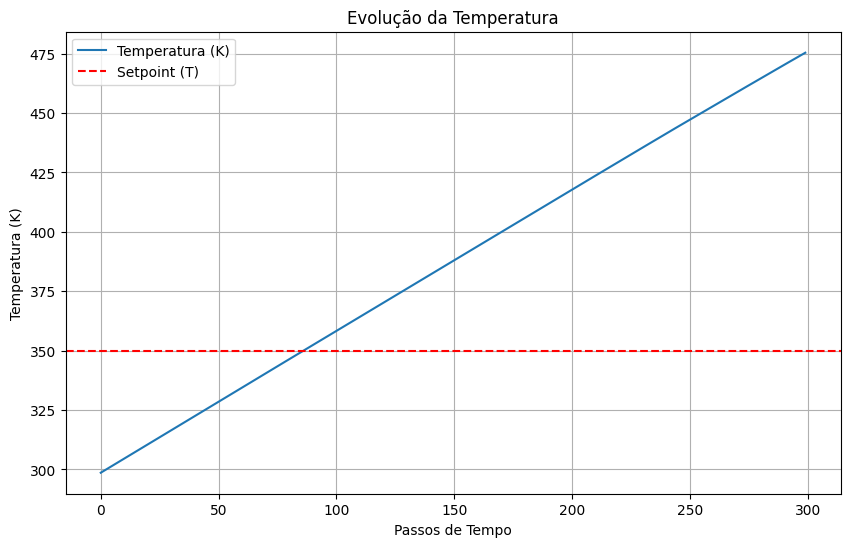

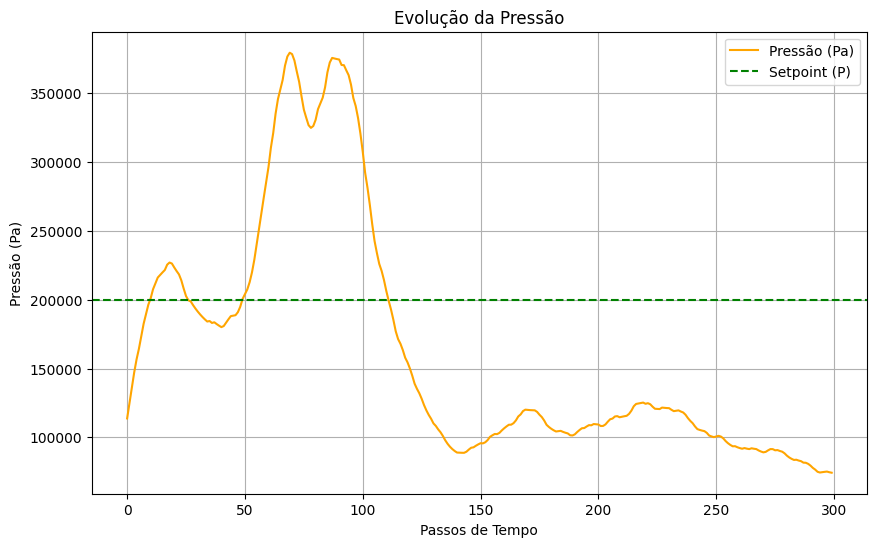

In [3]:
import numpy as np

# Criar o ambiente
env = CSTRControlEnv()

# Resetar o ambiente para iniciar
state = env.reset()

# Listas para armazenar dados para análise posterior
temperatures = []
pressures = []
rewards = []

# Loop de simulação com ações aleatórias
interactions = 0
while interactions<300:
    interactions+=1
    # Escolher uma ação aleatória
    action = env.action_space.sample()  # Amostra uma ação aleatória válida

    # Executar a ação no ambiente
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    #print(action,  next_state, reward)
    # Armazenar os valores de temperatura, pressão e recompensa
    temperatures.append(env.state["T"])
    pressures.append(env.state["P"])
    rewards.append(reward)

    # Atualizar o estado atual
    state = next_state

# Após o término, exibir os dados coletados
print("Simulação Concluída!")
print(f"Temperaturas: {temperatures}")
print(f"Pressões: {pressures}")
print(f"Recompensas Totais: {sum(rewards)}")

# Opcional: plotar os resultados
import matplotlib.pyplot as plt

time_steps = range(len(temperatures))

# Gráfico de Temperatura
plt.figure(figsize=(10, 6))
plt.plot(time_steps, temperatures, label="Temperatura (K)")
plt.axhline(env.params["T_setpoint"], color="red", linestyle="--", label="Setpoint (T)")
plt.xlabel("Passos de Tempo")
plt.ylabel("Temperatura (K)")
plt.title("Evolução da Temperatura")
plt.legend()
plt.grid()
plt.show()

# Gráfico de Pressão
plt.figure(figsize=(10, 6))
plt.plot(time_steps, pressures, label="Pressão (Pa)", color="orange")
plt.axhline(env.params["P_setpoint"], color="green", linestyle="--", label="Setpoint (P)")
plt.xlabel("Passos de Tempo")
plt.ylabel("Pressão (Pa)")
plt.title("Evolução da Pressão")
plt.legend()
plt.grid()
plt.show()


In [4]:
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt

class CustomEvalCallback(EvalCallback):
    def __init__(self, eval_env, eval_freq=1000, n_eval_episodes=5, log_path=None, verbose=1):
        """
        Callback personalizado para avaliação durante o treinamento.

        Args:
            eval_env: Ambiente de avaliação.
            eval_freq: Frequência em time steps para avaliação.
            n_eval_episodes: Número de episódios para cada avaliação.
            log_path: Caminho para salvar os logs.
            verbose: Nível de detalhamento (0 = silencioso, 1 = detalhes).
        """
        super().__init__(eval_env, eval_freq=eval_freq, n_eval_episodes=n_eval_episodes, log_path=log_path, verbose=verbose)
        self.best_reward = 0

    def _on_step(self) -> bool:
        """
        Método chamado em cada passo do treinamento para avaliação periódica.
        """
        result = super()._on_step()  # Realiza a avaliação padrão do EvalCallback

        # Verificar se estamos no momento de avaliação
        if self.n_calls % self.eval_freq == 0 and self.best_reward< self.last_mean_reward:
            self.best_reward = self.last_mean_reward
            # Imprimir métricas de avaliação
            print(f"\n[EVAL] Time Step: {self.n_calls}")
            print(f"Recompensa Média: {self.last_mean_reward:.2f}")

            # Executar o ambiente e coletar valores de pH
            obs = self.eval_env.reset()
            T_values = []
            P_values=[]
            flow0=[]
            flow1=[]
            interactions = 0
            while interactions<300:
                interactions+=1
                action, _ = self.model.predict(obs, deterministic=True)  # Predição determinística
                obs, reward, terminated, truncated = self.eval_env.step(action)
                T_values.append(self.eval_env.envs[0].state["T"])
                P_values.append(self.eval_env.envs[0].state["P"])
                flow0.append(self.eval_env.envs[0].coolant_flow)
                flow1.append(self.eval_env.envs[0].vent_flow)
            # Gráfico do T
            plt.figure(figsize=(5, 3))
            plt.plot(range(len(T_values))[:-2], T_values[:-2], label="T")
            plt.xlabel("Passos de Tempo")
            plt.ylabel("T")
            plt.title(f"Avaliação do T no Time Step {self.n_calls}")
            plt.legend()
            plt.grid()
            plt.show()
            # Gráfico do P
            plt.figure(figsize=(5, 3))
            plt.plot(range(len(P_values))[:-2], P_values[:-2], label="P")
            plt.xlabel("Passos de Tempo")
            plt.ylabel("P")
            plt.title(f"Avaliação do P no Time Step {self.n_calls}")
            plt.legend()
            plt.grid()
            plt.show()
            # Gráfico do vazoes
            plt.figure(figsize=(5, 3))
            plt.plot(range(len(flow0))[:-2], flow0[:-2], label="Vazao de agente resfriante")
            plt.plot(range(len(flow1))[:-2], flow1[:-2], label="Vazao de gas")
            plt.xlabel("Passos de Tempo")
            plt.ylabel("Vazoes  manipuladas")
            plt.title(f"Avaliação do P no Time Step {self.n_calls}")
            plt.legend()
            plt.grid()
            plt.show()
        return result


ModuleNotFoundError: No module named 'stable_baselines3'

In [ ]:
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.callbacks import EvalCallback
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3.common.evaluation import evaluate_policy


# Definir o ambiente Gym customizado
env = CSTRControlEnv()

# Hiperparâmetros do DQN
hyperparams = {'gamma': 0.92, 'learning_rate': 0.00001, 'buffer_size': 100000, 'batch_size': 512, 'exploration_fraction': 0.8, 'exploration_final_eps': 0.01, 'target_update_interval': 1000, 'train_freq': (2, 'episode'), 'gradient_steps': 1, 'policy_kwargs': {'net_arch': [64, 64]}}




In [ ]:
%%time
# Criar o modelo DQN
model1 = DQN(
    "MlpPolicy",
    env,
    gamma=hyperparams["gamma"],
    learning_rate=hyperparams["learning_rate"],
    buffer_size=hyperparams["buffer_size"],
    batch_size=hyperparams["batch_size"],
    exploration_fraction=hyperparams["exploration_fraction"],
    exploration_final_eps=hyperparams["exploration_final_eps"],
    target_update_interval=hyperparams["target_update_interval"],
    train_freq=hyperparams["train_freq"],
    gradient_steps=hyperparams["gradient_steps"],
    policy_kwargs=hyperparams["policy_kwargs"],
    verbose=0,
)
eval_callback = CustomEvalCallback(
    eval_env=env,
    eval_freq=50000,
    n_eval_episodes=5,
    verbose=1,
)
model1.learn(total_timesteps=7000000, callback=eval_callback)
